In [121]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [152]:
df =  pd.read_csv('datasets-day-2/dataset-1.csv')
df.head()

,target,x1,x2,x3,x4,x5,x6,x7,x8
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [123]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   target  398 non-null    float64
 1   x1      398 non-null    int64  
 2   x2      398 non-null    float64
 3   x3      398 non-null    object 
 4   x4      398 non-null    int64  
 5   x5      398 non-null    float64
 6   x6      398 non-null    int64  
 7   x7      398 non-null    int64  
 8   x8      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB


In [124]:
df.describe()

,target,x1,x2,x4,x5,x6,x7
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,5140.000000,24.800000,82.000000,3.000000


In [125]:
%pip install missingno

Note: you may need to restart the kernel to use updated packages.


<Axes: >

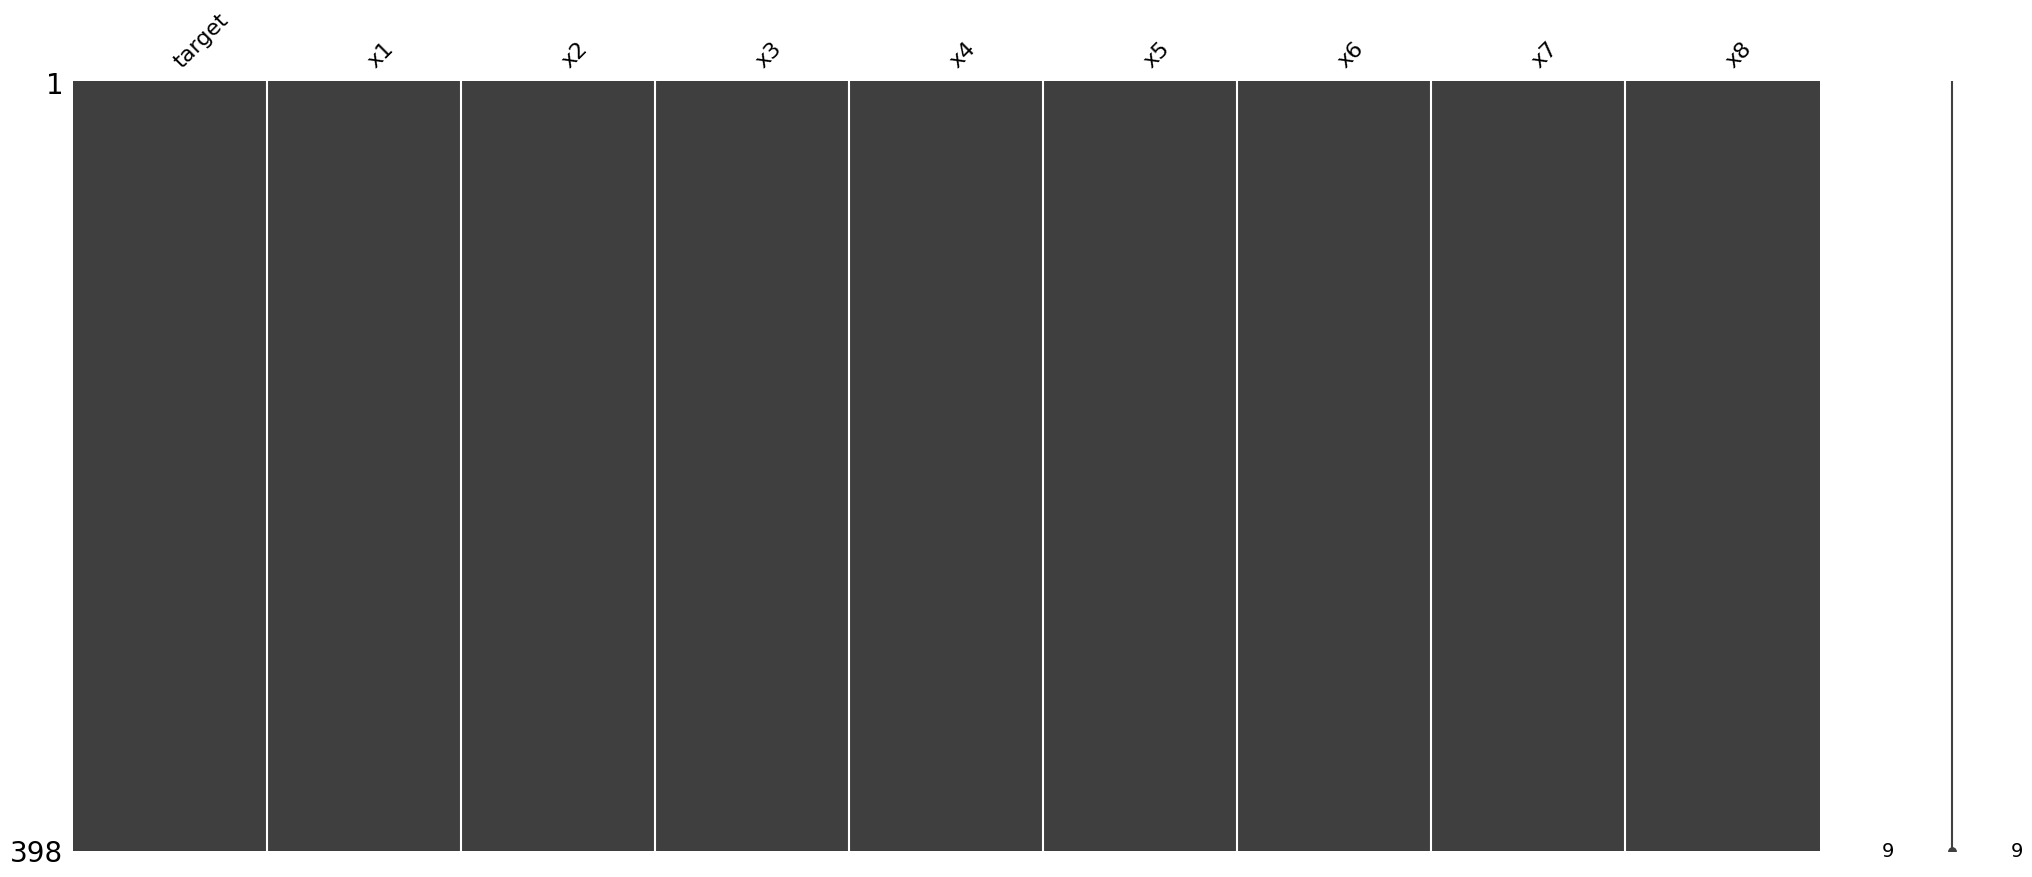

In [126]:
import missingno as msn
msn.matrix(df)

In [127]:
df.isnull().sum()

target    0
x1        0
x2        0
x3        0
x4        0
x5        0
x6        0
x7        0
x8        0
dtype: int64

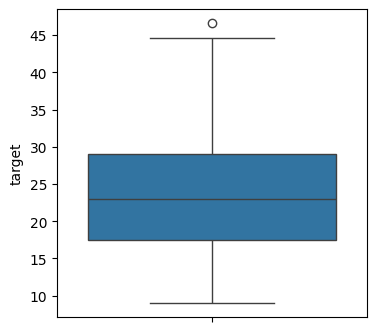

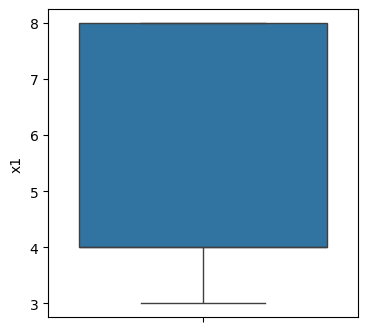

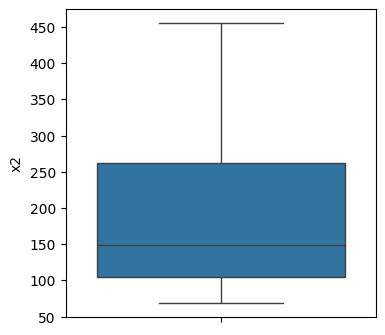

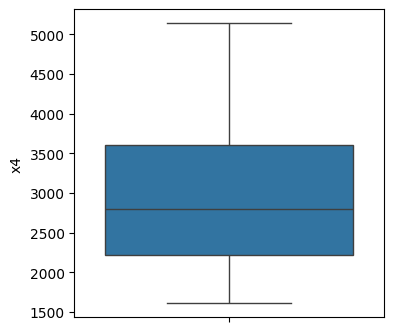

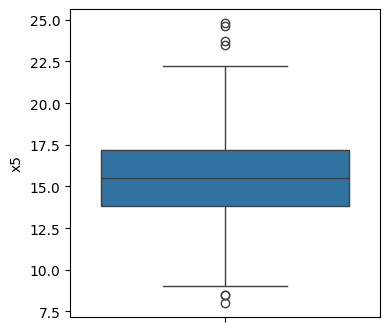

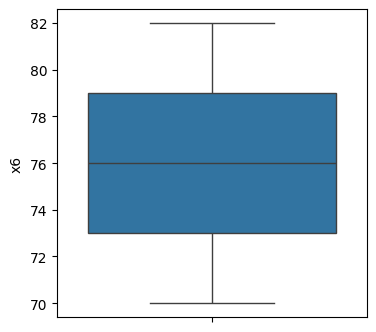

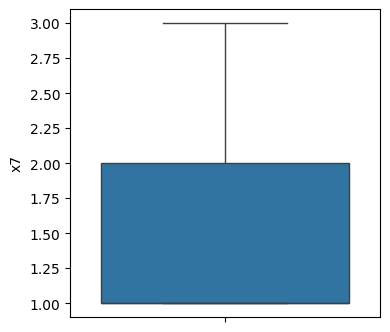

In [128]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
for i in df.columns:
    
    if i in numerical_cols:
        plt.figure(figsize=(4,4))
        sns.boxplot(df[i])
        plt.show()

In [129]:
df['x8'].nunique()

305

In [130]:
'''for i in df['x8']:
    df[i]=i.lower().strip().replace("@","")
df['x8']'''

'for i in df[\'x8\']:\n    df[i]=i.lower().strip().replace("@","")\ndf[\'x8\']'

In [131]:
df['x8'].head()

0    chevrolet chevelle malibu
1            buick skylark 320
2           plymouth satellite
3                amc rebel sst
4                  ford torino
Name: x8, dtype: object

In [153]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   target  398 non-null    float64
 1   x1      398 non-null    int64  
 2   x2      398 non-null    float64
 3   x3      398 non-null    object 
 4   x4      398 non-null    int64  
 5   x5      398 non-null    float64
 6   x6      398 non-null    int64  
 7   x7      398 non-null    int64  
 8   x8      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB


X3 has ? --> replace to nan --> type to float

In [133]:
df['x3'] = df['x3'].replace('?', np.nan).astype('float64')

In [134]:
df['x3'].isnull().sum()

np.int64(6)

In [135]:
q1 = df['x3'].quantile(0.25)
q3 = df['x3'].quantile(0.75)

iqr = q3-q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = df[(df['x3']< lower_bound ) | (df['x3']> upper_bound)]

outliers

,target,x1,x2,x3,x4,x5,x6,x7,x8
6,14.0,8,454.0,220.0,4354,9.0,70,1,chevrolet impala
7,14.0,8,440.0,215.0,4312,8.5,70,1,plymouth fury iii
8,14.0,8,455.0,225.0,4425,10.0,70,1,pontiac catalina
13,14.0,8,455.0,225.0,3086,10.0,70,1,buick estate wagon (sw)
25,10.0,8,360.0,215.0,4615,14.0,70,1,ford f250
27,11.0,8,318.0,210.0,4382,13.5,70,1,dodge d200
67,11.0,8,429.0,208.0,4633,11.0,72,1,mercury marquis
94,13.0,8,440.0,215.0,4735,11.0,73,1,chrysler new yorker brougham
95,12.0,8,455.0,225.0,4951,11.0,73,1,buick electra 225 custom
116,16.0,8,400.0,230.0,4278,9.5,73,1,pontiac grand prix


FIll null Values

In [136]:
from sklearn.impute import SimpleImputer

impute = SimpleImputer(strategy='median')
df['x3']=impute.fit_transform(df[['x3']])

In [137]:
df['x3'].isnull().sum()

np.int64(0)

In [138]:
df['x3'].dtype

dtype('float64')

Heatmap

<Axes: >

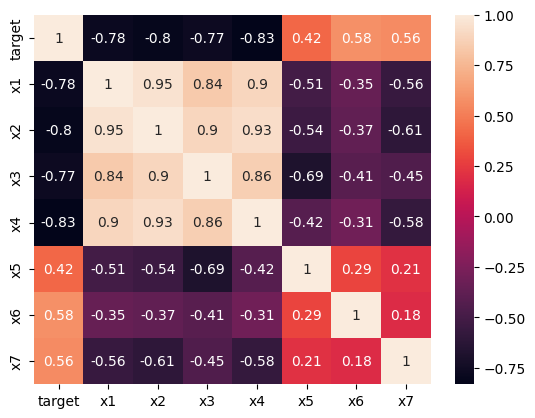

In [139]:
sns.heatmap(df.select_dtypes(include=['int64','float64']).corr(),annot=True)

In [140]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   target  398 non-null    float64
 1   x1      398 non-null    int64  
 2   x2      398 non-null    float64
 3   x3      398 non-null    float64
 4   x4      398 non-null    int64  
 5   x5      398 non-null    float64
 6   x6      398 non-null    int64  
 7   x7      398 non-null    int64  
 8   x8      398 non-null    object 
dtypes: float64(4), int64(4), object(1)
memory usage: 28.1+ KB


In [154]:
X=df.drop('target',axis=1)
y=df['target']


In [155]:
num_col = X.select_dtypes(include=['int64','float64'])
cat_col =X.select_dtypes(include=['object'])


In [156]:
cat_col

,x3,x8
0,130,chevrolet chevelle malibu
1,165,buick skylark 320
2,150,plymouth satellite
3,150,amc rebel sst
4,140,ford torino
...,...,...
393,86,ford mustang gl
394,52,vw pickup
395,84,dodge rampage
396,79,ford ranger


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
X['x8_enc'] = le.fit_transform(X['x8'])

X.head(15)


,x1,x2,x3,x4,x5,x6,x7,x8,x8_enc
0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu,49
1,8,350.0,165,3693,11.5,70,1,buick skylark 320,36
2,8,318.0,150,3436,11.0,70,1,plymouth satellite,231
3,8,304.0,150,3433,12.0,70,1,amc rebel sst,14
4,8,302.0,140,3449,10.5,70,1,ford torino,161
5,8,429.0,198,4341,10.0,70,1,ford galaxie 500,141
6,8,454.0,220,4354,9.0,70,1,chevrolet impala,54
7,8,440.0,215,4312,8.5,70,1,plymouth fury iii,223
8,8,455.0,225,4425,10.0,70,1,pontiac catalina,241
9,8,390.0,190,3850,8.5,70,1,amc ambassador dpl,1


In [179]:

with open('encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

In [86]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [87]:
from sklearn.preprocessing import StandardScaler
std = StandardScaler()

x_train_std = std.fit_transform(x_train)
x_test = std.transform(x_test)

In [178]:
with open('scaler.pkl', 'wb') as f:
    pickle.dump(std, f)

<h1>Linear reg</h1>

In [88]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(x_train_std,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [89]:
y_pred = lr.predict(x_test)


In [90]:
from sklearn.metrics import mean_squared_error,r2_score,root_mean_squared_error

print("mean sq error :", mean_squared_error(y_test,y_pred))

print("r2_score :", r2_score(y_test,y_pred))

print("root_mean_squared_error :", root_mean_squared_error(y_test,y_pred))


mean sq error : 8.246128635400293
r2_score : 0.8466305736391522
root_mean_squared_error : 2.871607326115514


<H1>poly</h1>

In [91]:
from sklearn.preprocessing import PolynomialFeatures

ply= PolynomialFeatures(degree=2)
x_train_std_poly = ply.fit_transform(x_train_std)
x_test_poly = ply.transform(x_test)



In [92]:
model = LinearRegression()
model.fit(x_train_std_poly, y_train)
y_pred_poly = model.predict(x_test_poly)

print("Mean Squared Error:", mean_squared_error(y_test, y_pred_poly))
print("R2 Score:", r2_score(y_test, y_pred_poly))
print("Root Mean Squared Error:", root_mean_squared_error(y_test, y_pred_poly))

Mean Squared Error: 6.031474130698166
R2 Score: 0.8878208467953924
Root Mean Squared Error: 2.45590596943331


<h1>SVR</h1>

In [93]:
from sklearn.svm import SVR

svm = SVR(kernel='rbf',C=100,epsilon=0.1,gamma=0.1)
svm.fit(x_train_std,y_train)


,kernel,'rbf'
,degree,3
,gamma,0.1
,coef0,0.0
,tol,0.001
,C,100
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [94]:
from sklearn.model_selection import GridSearchCV
svr = SVR()
svr_params = {
    'kernel': ['linear', 'rbf', 'poly'],
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1],
    'epsilon': [0.01, 0.1, 0.2, 0.5]
}
svr_grid = GridSearchCV(
    estimator=svr,
    param_grid=svr_params,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=2
)
svr_grid.fit(x_train_std, y_train)
print("=" * 50)
print("SVR - Best Parameters:", svr_grid.best_params_)
print("SVR - Best Score:", -svr_grid.best_score_)
print("=" * 50)


Fitting 3 folds for each of 240 candidates, totalling 720 fits
SVR - Best Parameters: {'C': 100, 'epsilon': 0.1, 'gamma': 0.01, 'kernel': 'rbf'}
SVR - Best Score: 8.893796700940166


In [95]:
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error,mean_absolute_error   
y_pred_svr = svm.predict(x_test)

print("Mean Squared Error:", mean_squared_error(y_test, y_pred_svr))
print("R2 Score:", r2_score(y_test, y_pred_svr))
print("Root Mean Squared Error:", root_mean_squared_error(y_test, y_pred_svr))
print("Root Mean absolute Error:", mean_absolute_error(y_test, y_pred_svr))

Mean Squared Error: 3.9369977245196424
R2 Score: 0.9267759321627136
Root Mean Squared Error: 1.9841869177372484
Root Mean absolute Error: 1.5126150304368413


SVM is the High Accuracy model

In [96]:
import pickle

with open('svm_model.pkl', 'wb') as file:
    pickle.dump(svm, file)
print("SVM model saved to svm_model.pkl")

SVM model saved to svm_model.pkl


<h1>Dt</h1>

In [170]:
from sklearn.tree import DecisionTreeRegressor

dtr = DecisionTreeRegressor(criterion='squared_error',max_depth=None,max_features='log2',min_samples_leaf=4,min_samples_split=2,random_state=42,splitter='best')
dtr.fit(x_train_std,y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,4
,min_weight_fraction_leaf,0.0
,max_features,'log2'
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [98]:
dtr = DecisionTreeRegressor(random_state=42)
dtr_params = {
    'max_depth': [None, 5, 10, 15, 20, 30],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': ['auto', 'sqrt', 'log2', None],
    'splitter': ['best', 'random']
}
dtr_grid = GridSearchCV(
    estimator=dtr,
    param_grid=dtr_params,
    cv=2,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=2
)
dtr_grid.fit(x_train_std, y_train)
print("=" * 50)
print("DTR - Best Parameters:", dtr_grid.best_params_)
print("DTR - Best Score:", -dtr_grid.best_score_)
print("=" * 50)

Fitting 2 folds for each of 768 candidates, totalling 1536 fits


DTR - Best Parameters: {'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 4, 'min_samples_split': 2, 'splitter': 'best'}
DTR - Best Score: 11.264828925469558


c:\Users\AKASH\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
384 fits failed out of a total of 1536.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
261 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\AKASH\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\AKASH\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py", line 1358, in wrapper
    estimator._validate_params()
  File "c:\Users\AKASH\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\bas

In [171]:
y_pred_dt = dtr.predict(x_test)

print("Mean Squared Error:", mean_squared_error(y_test, y_pred_dt))
print("R2 Score:", r2_score(y_test, y_pred_dt))
print("Root Mean Squared Error:", root_mean_squared_error(y_test, y_pred_dt))

Mean Squared Error: 8.228836093395692
R2 Score: 0.8469521969565694
Root Mean Squared Error: 2.8685947942147028


<h1>Random forest</h1>

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rfr = RandomForestRegressor(criterion='squared_error',n_estimators=100)
rfr.fit(x_train_std,y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
y_pred_rf = rfr.predict(x_test)

print("Mean Squared Error:", mean_squared_error(y_test, y_pred_rf))
print("R2 Score:", r2_score(y_test, y_pred_rf))
print("Root Mean Squared Error:", root_mean_squared_error(y_test, y_pred_rf))

Mean Squared Error: 4.518130837499994
R2 Score: 0.9159674599549836
Root Mean Squared Error: 2.1255895270489065


In [182]:

# Load all three pickle files
with open('svm_model.pkl', 'rb') as f:
    svm_model = pickle.load(f)
with open('scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)
with open('encoder.pkl', 'rb') as f:
    label_encoder = pickle.load(f)
# Raw input data
x1, x2, x3, x4, x5, x6, x7 = 4, 97, 46, 1835, 20.5, 70, 2
x8 = "volkswagen 1131 deluxe sedan"
x8_encoded = label_encoder.transform([x8])[0]

input = np.array([[x1, x2, x3, x4, x5, x6, x7, x8_encoded]])
i_s = std.transform(input)

print("SVM:", svm.predict(i_s))
print("RFR :", rfr.predict(i_s))
print("DT :", dtr.predict(i_s))
print("l :", lr.predict(i_s))




SVM: [25.90013712]
RFR : [27.176]
DT : [28.14285714]
l : [27.43542606]


c:\Users\AKASH\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
